Confidence Gating for Robust Segmentation
Step 3 in the pipeline. This notebook loads the baseline checkpoint (notebook 1), applies the shift setup (notebook 2), and studies confidence-threshold gating under corruption.

Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

DATA = ROOT / "data"
WEIGHTS = ROOT / "weights"
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

import torch
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
torch.backends.cudnn.benchmark = True

torch: 2.10.0+cu128
cuda: True
gpu: NVIDIA GeForce RTX 5070


Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
import torchvision.transforms.functional as TF

from src.dataset_cityscapes import CityscapesTrainId
from src.train_utils import get_device, make_deeplab, load_checkpoint
from src.metrics import confusion_matrix, miou_from_cm

Load datasets (clean + one corruption)

In [3]:
# Keep default resolution for first run; replaced by checkpoint resolution later if needed.
SIZE_HW = (512, 1024)

val_clean = CityscapesTrainId(DATA, split="val", size_hw=SIZE_HW)

class CorruptWrapper(torch.utils.data.Dataset):
    def __init__(self, base_ds, mode: str):
        self.base = base_ds
        self.mode = mode

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y, meta = self.base[idx]

        # Match notebook 2 corruption strengths so comparisons stay consistent.
        if self.mode == "blur":
            x = TF.gaussian_blur(x, kernel_size=7, sigma=1.35)
        elif self.mode == "noise":
            x = x + 0.14 * torch.randn_like(x)
            x = torch.clamp(x, -3.0, 3.0)
        elif self.mode == "bright":
            x = x * 1.25
            x = torch.clamp(x, -3.0, 3.0)
        else:
            raise ValueError(f"Unknown corruption mode: {self.mode}")

        meta = dict(meta)
        meta["corruption"] = self.mode
        return x, y, meta

val_corrupt = CorruptWrapper(val_clean, mode="blur")

DataLoaders

In [4]:
def make_loader(ds, bs=4, shuffle=False, num_workers=0, pin_memory=False):
    return DataLoader(
        ds, batch_size=bs, shuffle=shuffle,
        num_workers=num_workers, pin_memory=pin_memory,
        persistent_workers=(num_workers > 0), drop_last=False
    )

BATCH_SIZE = 4
NUM_WORKERS_CLEAN = 4
NUM_WORKERS_CORRUPT = 0  # Wrapper datasets are usually safer this way on Windows.
PIN_MEMORY = torch.cuda.is_available()

loader_clean = make_loader(
    val_clean, bs=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS_CLEAN, pin_memory=PIN_MEMORY
    )
loader_corrupt = make_loader(
    val_corrupt, bs=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS_CORRUPT, pin_memory=PIN_MEMORY
    )

print("Loaders ready:", len(loader_clean), len(loader_corrupt))
print("workers clean/corrupt:", NUM_WORKERS_CLEAN, NUM_WORKERS_CORRUPT)

Loaders ready: 125 125
workers clean/corrupt: 4 0


Load model

In [5]:
device = get_device()

ckpt_path = WEIGHTS / "deeplabv3_cityscapes_baseline.pt"
model = make_deeplab(num_classes=19, pretrained=True).to(device)
ckpt = load_checkpoint(ckpt_path, model, map_location=device)
trained_size_hw = ckpt.get("size_hw", SIZE_HW)
print("Loaded:", ckpt_path)
print("Trained size_hw:", trained_size_hw)

# Rebuild validation datasets/loaders at checkpoint resolution if needed.
if tuple(trained_size_hw) != tuple(SIZE_HW):
    SIZE_HW = tuple(trained_size_hw)
    val_clean = CityscapesTrainId(DATA, split="val", size_hw=SIZE_HW)
    val_corrupt = CorruptWrapper(val_clean, mode="blur")

    loader_clean = make_loader(
        val_clean, bs=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS_CLEAN, pin_memory=PIN_MEMORY
    )
    loader_corrupt = make_loader(
        val_corrupt, bs=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS_CORRUPT, pin_memory=PIN_MEMORY
    )
    print("Rebuilt loaders at checkpoint size:", SIZE_HW, "| batches:", len(loader_clean))

Loaded: c:\Users\dhruv\temporal_cityscapes\weights\deeplabv3_cityscapes_baseline.pt
Trained size_hw: (512, 1024)


Helper: forward pass returning prediction + confidence

In [6]:
@torch.no_grad()
def pred_and_confidence(model, x):
    model.eval()
    logits = model(x)["out"]                     # [N,C,H,W]
    probs = torch.softmax(logits, dim=1)         # [N,C,H,W]
    conf, pred = probs.max(dim=1)                # [N,H,W], [N,H,W]
    return pred, conf, logits

Metric: disagreement + coverage
Disagreement is measured vs clean prediction (pseudo-ground-truth for stability).
Coverage = fraction of pixels above threshold.

In [7]:
@torch.no_grad()
def disagreement_and_coverage(pred_clean, pred_corrupt, conf_corrupt, tau: float, ignore_mask: torch.Tensor):
    """
    ignore_mask: True where we should ignore pixels (gt == 255)
    """
    keep = (conf_corrupt >= tau) & (~ignore_mask)
    coverage = keep.float().mean().item()

    disagree = ((pred_clean != pred_corrupt) & keep).float().mean().item() if coverage > 0 else 0.0
    return disagree, coverage

Compute baseline mIoU (clean vs corrupt)

In [8]:
import time

@torch.no_grad()
def eval_miou(model, loader, num_classes=19, ignore_index=255, progress_every=10, name="eval"):
    cm_total = torch.zeros((num_classes, num_classes), device=device, dtype=torch.int64)
    model.eval()
    t0 = time.time()
    total_batches = len(loader)

    for batch_idx, (x, y, _) in enumerate(loader, start=1):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)["out"]
        pred = logits.argmax(dim=1)
        cm_total += confusion_matrix(pred, y, num_classes, ignore_index).to(device)

        if (batch_idx % max(1, progress_every) == 0) or (batch_idx == total_batches):
            elapsed = time.time() - t0
            pct = 100.0 * batch_idx / max(1, total_batches)
            rate = elapsed / max(1, batch_idx)
            eta = max(0.0, (total_batches - batch_idx) * rate)
            print(
                f"[{name}] {batch_idx}/{total_batches} ({pct:5.1f}%)"
                f" | elapsed {elapsed:.1f}s | eta {eta:.1f}s",
                flush=True,
            )

    miou, iou_pc = miou_from_cm(cm_total.cpu())
    return miou, iou_pc

miou_clean, _ = eval_miou(model, loader_clean, progress_every=10, name="clean")
miou_corrupt, _ = eval_miou(model, loader_corrupt, progress_every=10, name="blur")

print("mIoU clean:", round(miou_clean, 4))
print("mIoU corrupt (blur):", round(miou_corrupt, 4))

[clean] 10/125 (  8.0%) | elapsed 24.6s | eta 282.6s
[clean] 20/125 ( 16.0%) | elapsed 26.0s | eta 136.4s
[clean] 30/125 ( 24.0%) | elapsed 27.4s | eta 86.6s
[clean] 40/125 ( 32.0%) | elapsed 28.7s | eta 61.1s
[clean] 50/125 ( 40.0%) | elapsed 30.2s | eta 45.3s
[clean] 60/125 ( 48.0%) | elapsed 31.6s | eta 34.2s
[clean] 70/125 ( 56.0%) | elapsed 33.0s | eta 25.9s
[clean] 80/125 ( 64.0%) | elapsed 34.4s | eta 19.3s
[clean] 90/125 ( 72.0%) | elapsed 35.8s | eta 13.9s
[clean] 100/125 ( 80.0%) | elapsed 37.1s | eta 9.3s
[clean] 110/125 ( 88.0%) | elapsed 38.5s | eta 5.3s
[clean] 120/125 ( 96.0%) | elapsed 39.9s | eta 1.7s
[clean] 125/125 (100.0%) | elapsed 40.6s | eta 0.0s
[blur] 10/125 (  8.0%) | elapsed 4.2s | eta 48.0s
[blur] 20/125 ( 16.0%) | elapsed 8.2s | eta 43.2s
[blur] 30/125 ( 24.0%) | elapsed 12.3s | eta 38.9s
[blur] 40/125 ( 32.0%) | elapsed 16.3s | eta 34.7s
[blur] 50/125 ( 40.0%) | elapsed 20.4s | eta 30.6s
[blur] 60/125 ( 48.0%) | elapsed 24.5s | eta 26.5s
[blur] 70/125 ( 56

Confidence gating sweep
We sweep thresholds and measure:

disagreement (lower is better)

coverage (higher is better)

In [9]:
import time

taus = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
stats = []

model.eval()
total_taus = len(taus)
overall_t0 = time.time()

for tau_idx, tau in enumerate(taus, start=1):
    tau_t0 = time.time()
    disag_list = []
    cov_list = []
    total_batches = min(len(loader_clean), len(loader_corrupt))

    print(f"\n[tau {tau:.2f}] start ({tau_idx}/{total_taus})")

    # Zipped loaders stay aligned because both datasets share ordering/indexing.
    for batch_idx, ((x0, y0, _), (x1, y1, _)) in enumerate(zip(loader_clean, loader_corrupt), start=1):
        x0 = x0.to(device, non_blocking=True)
        x1 = x1.to(device, non_blocking=True)
        y0 = y0.to(device, non_blocking=True)

        pred0, _, _ = pred_and_confidence(model, x0)
        pred1, conf1, _ = pred_and_confidence(model, x1)

        ignore_mask = (y0 == 255)
        d, c = disagreement_and_coverage(pred0, pred1, conf1, tau=tau, ignore_mask=ignore_mask)

        disag_list.append(d)
        cov_list.append(c)

        if (batch_idx % 10 == 0) or (batch_idx == total_batches):
            elapsed = time.time() - tau_t0
            pct = 100.0 * batch_idx / max(1, total_batches)
            rate = elapsed / max(1, batch_idx)
            eta = max(0.0, (total_batches - batch_idx) * rate)
            print(
                f"[tau {tau:.2f}] {batch_idx}/{total_batches} ({pct:5.1f}%)"
                f" | elapsed {elapsed:.1f}s | eta {eta:.1f}s",
                flush=True,
            )

    tau_dis = float(np.mean(disag_list))
    tau_cov = float(np.mean(cov_list))
    stats.append((tau, tau_dis, tau_cov))
    print(
        f"[tau {tau:.2f}] done in {time.time() - tau_t0:.1f}s"
        f" | disagree={tau_dis:.4f} | coverage={tau_cov:.4f}",
        flush=True,
    )

print(f"\nAll thresholds done in {time.time() - overall_t0:.1f}s")
stats


[tau 0.30] start (1/6)
[tau 0.30] 10/125 (  8.0%) | elapsed 6.3s | eta 72.0s
[tau 0.30] 20/125 ( 16.0%) | elapsed 11.8s | eta 61.9s
[tau 0.30] 30/125 ( 24.0%) | elapsed 17.2s | eta 54.5s
[tau 0.30] 40/125 ( 32.0%) | elapsed 22.8s | eta 48.4s
[tau 0.30] 50/125 ( 40.0%) | elapsed 28.3s | eta 42.4s
[tau 0.30] 60/125 ( 48.0%) | elapsed 33.9s | eta 36.7s
[tau 0.30] 70/125 ( 56.0%) | elapsed 39.4s | eta 31.0s
[tau 0.30] 80/125 ( 64.0%) | elapsed 44.9s | eta 25.3s
[tau 0.30] 90/125 ( 72.0%) | elapsed 50.6s | eta 19.7s
[tau 0.30] 100/125 ( 80.0%) | elapsed 56.3s | eta 14.1s
[tau 0.30] 110/125 ( 88.0%) | elapsed 61.9s | eta 8.4s
[tau 0.30] 120/125 ( 96.0%) | elapsed 67.3s | eta 2.8s
[tau 0.30] 125/125 (100.0%) | elapsed 69.9s | eta 0.0s
[tau 0.30] done in 69.9s | disagree=0.0693 | coverage=0.8733

[tau 0.40] start (2/6)
[tau 0.40] 10/125 (  8.0%) | elapsed 6.1s | eta 69.9s
[tau 0.40] 20/125 ( 16.0%) | elapsed 11.7s | eta 61.2s
[tau 0.40] 30/125 ( 24.0%) | elapsed 17.1s | eta 54.2s
[tau 0.40] 4

[(0.3, 0.06933497619628906, 0.8733069572448731),
 (0.4, 0.06603977584838867, 0.8680838928222656),
 (0.5, 0.05912823104858399, 0.8552421989440918),
 (0.6, 0.04638938903808594, 0.827041675567627),
 (0.7, 0.035793899536132816, 0.797477409362793),
 (0.8, 0.026171123504638672, 0.7622846069335938)]

Print results cleanly + save

In [10]:
print("Confidence gating results (corruption=blur):")
print(" tau | disagree | coverage")
for tau, d, c in stats:
    print(f"{tau:>4.2f} | {d:>8.4f} | {c:>8.4f}")

# Save for report
save_path = OUT / "confidence_gating_blur.txt"
with open(save_path, "w") as f:
    for tau, d, c in stats:
        f.write(f"tau={tau:.2f} disagree={d:.6f} coverage={c:.6f}\n")
print("Saved:", save_path)

Confidence gating results (corruption=blur):
 tau | disagree | coverage
0.30 |   0.0693 |   0.8733
0.40 |   0.0660 |   0.8681
0.50 |   0.0591 |   0.8552
0.60 |   0.0464 |   0.8270
0.70 |   0.0358 |   0.7975
0.80 |   0.0262 |   0.7623
Saved: c:\Users\dhruv\temporal_cityscapes\outputs\confidence_gating_blur.txt


Plot disagreement vs threshold

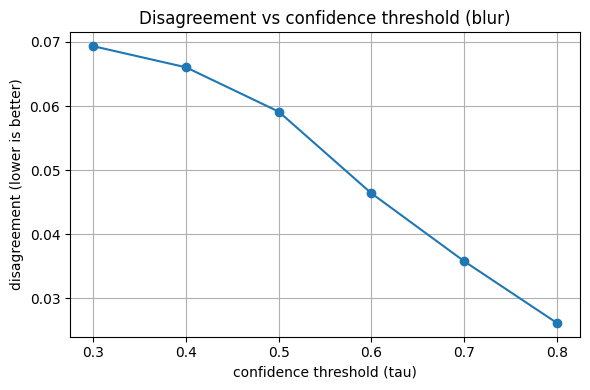

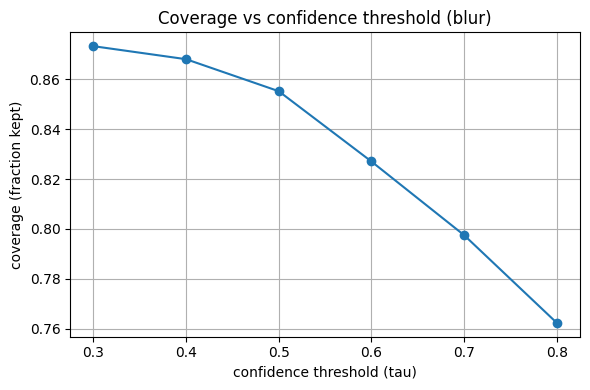

In [11]:
taus_arr = [t for t,_,_ in stats]
dis_arr  = [d for _,d,_ in stats]
cov_arr  = [c for _,_,c in stats]

plt.figure(figsize=(6,4))
plt.plot(taus_arr, dis_arr, marker="o")
plt.xlabel("confidence threshold (tau)")
plt.ylabel("disagreement (lower is better)")
plt.title("Disagreement vs confidence threshold (blur)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(taus_arr, cov_arr, marker="o")
plt.xlabel("confidence threshold (tau)")
plt.ylabel("coverage (fraction kept)")
plt.title("Coverage vs confidence threshold (blur)")
plt.grid(True)
plt.tight_layout()
plt.show()

Qualitative: show where pixels are filtered

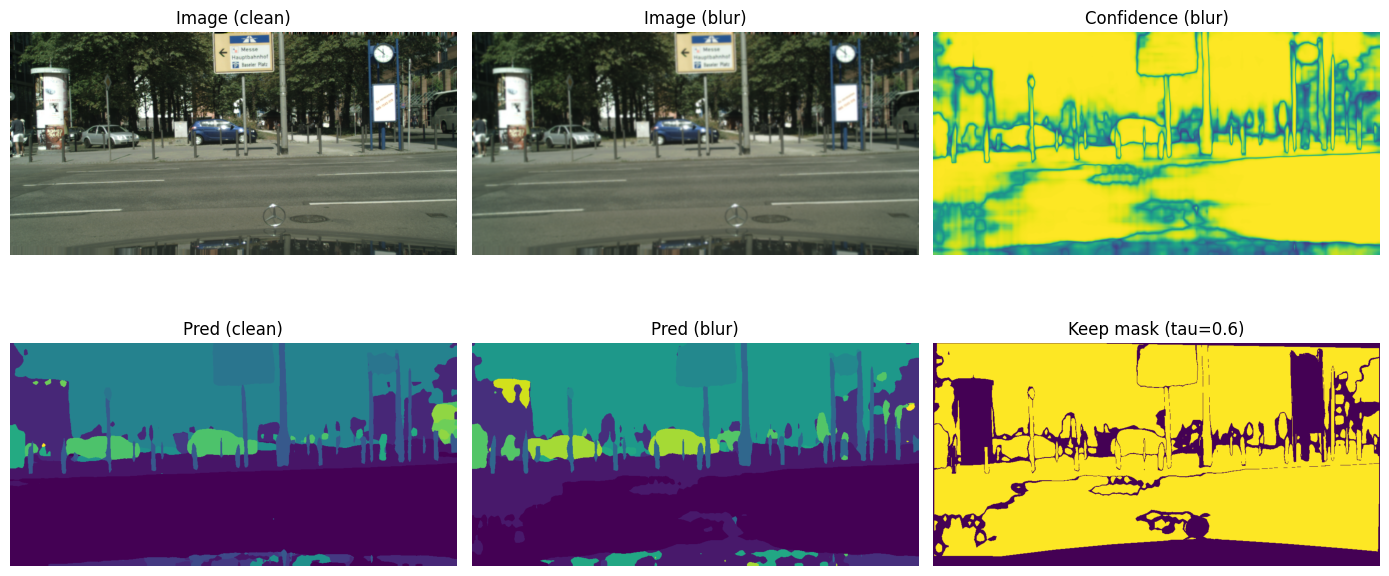

In [12]:
@torch.no_grad()
def denorm_img(x):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = x.cpu() * std + mean
    return torch.clamp(img, 0, 1)

def show_gating_example(idx=25, tau=0.6):
    x0, y0, _ = val_clean[idx]
    x1, _, _  = val_corrupt[idx]

    x0d = denorm_img(x0)
    x1d = denorm_img(x1)

    x0b = x0.unsqueeze(0).to(device)
    x1b = x1.unsqueeze(0).to(device)
    y0b = y0.unsqueeze(0).to(device)

    pred0, _, _ = pred_and_confidence(model, x0b)
    pred1, conf1, _ = pred_and_confidence(model, x1b)

    pred0 = pred0.squeeze(0).cpu()
    pred1 = pred1.squeeze(0).cpu()
    conf1 = conf1.squeeze(0).cpu()
    ignore = (y0 == 255)

    keep = (conf1 >= tau) & (~ignore)

    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    axes[0,0].imshow(x0d.permute(1,2,0)); axes[0,0].set_title("Image (clean)")
    axes[0,1].imshow(x1d.permute(1,2,0)); axes[0,1].set_title("Image (blur)")
    axes[0,2].imshow(conf1, vmin=0, vmax=1); axes[0,2].set_title("Confidence (blur)")

    axes[1,0].imshow(pred0); axes[1,0].set_title("Pred (clean)")
    axes[1,1].imshow(pred1); axes[1,1].set_title("Pred (blur)")
    axes[1,2].imshow(keep);  axes[1,2].set_title(f"Keep mask (tau={tau})")

    for ax in axes.flat:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_gating_example(idx=25, tau=0.6)